In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Lasso, Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')


In [ ]:
print("="*60)
print("HOUSE PRICES - ADVANCED REGRESSION TECHNIQUES")
print("="*60)

HOUSE PRICES - ADVANCED REGRESSION TECHNIQUES


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
train = pd.read_csv('/content/drive/MyDrive/Advanced Machine Learning/train.csv')
test = pd.read_csv('/content/drive/MyDrive/Advanced Machine Learning/test.csv')
test_ID = test['Id']

In [ ]:
print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")

Train shape: (1460, 81)
Test shape: (1459, 80)


In [ ]:
print("\n[2] Exploratory Data Analysis...")
print("\nTarget Variable (SalePrice) Statistics:")
print(train['SalePrice'].describe())
print(f"\nSkewness: {train['SalePrice'].skew():.4f}")


[2] Exploratory Data Analysis...

Target Variable (SalePrice) Statistics:
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

Skewness: 1.8829


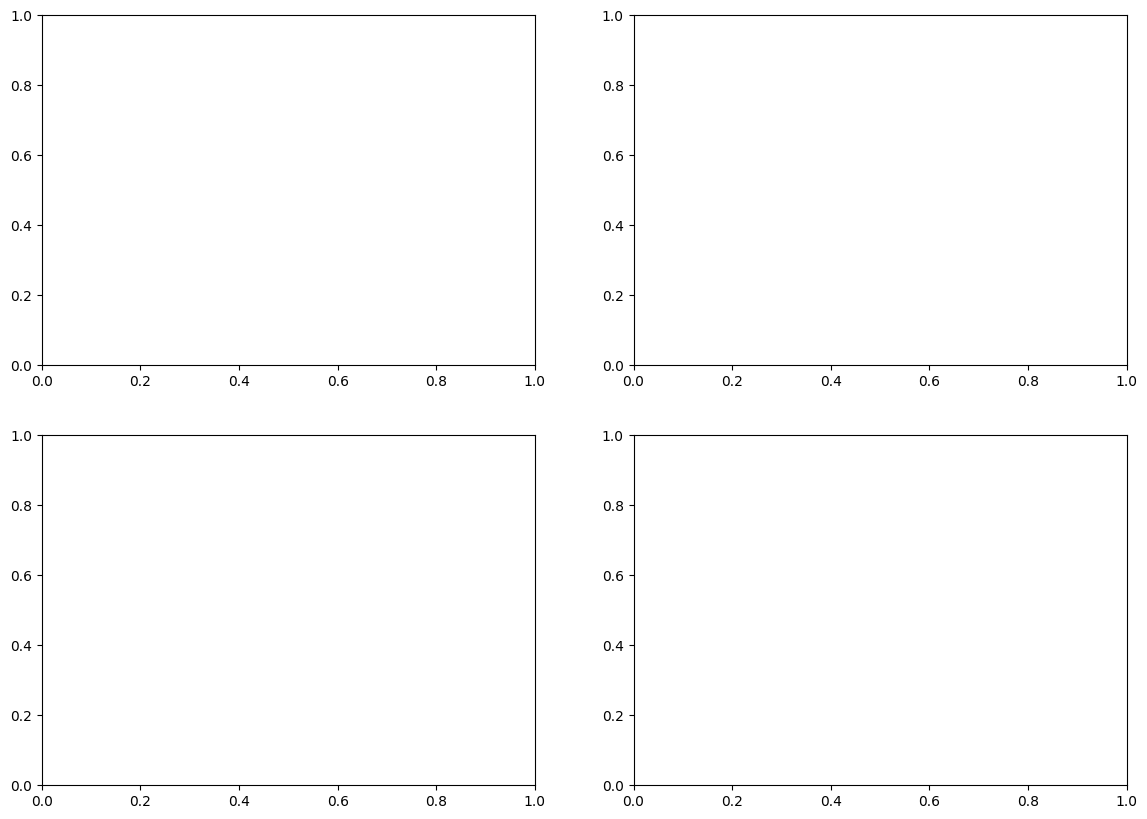

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

In [ ]:
sns.histplot(train['SalePrice'], kde=True, ax=axes[0,0])
axes[0,0].set_title('SalePrice Distribution')

Text(0.5, 1.0, 'SalePrice Distribution')

In [ ]:
sns.histplot(np.log1p(train['SalePrice']), kde=True, ax=axes[0,1], color='green')
axes[0,1].set_title('Log-Transformed SalePrice Distribution')

Text(0.5, 1.0, 'Log-Transformed SalePrice Distribution')

In [ ]:
numeric_train = train.select_dtypes(include=np.number)
correlations = numeric_train.corr()['SalePrice'].sort_values(ascending=False)
top_corr = correlations[1:11]
sns.barplot(x=top_corr.values, y=top_corr.index, ax=axes[1,0])
axes[1,0].set_title('Top 10 Features Correlated with SalePrice')

Text(0.5, 1.0, 'Top 10 Features Correlated with SalePrice')

In [ ]:
missing = train.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0].head(10)
if len(missing) > 0:
    sns.barplot(x=missing.values, y=missing.index, ax=axes[1,1])
    axes[1,1].set_title('Top 10 Features with Missing Values')
else:
    axes[1,1].text(0.5, 0.5, 'No Missing Values', ha='center', va='center')
    axes[1,1].set_title('Missing Values')

plt.tight_layout()
plt.savefig('eda_analysis.png', dpi=300, bbox_inches='tight')
print("✓ EDA visualizations saved as 'eda_analysis.png'")

print(f"\nTop 5 features correlated with SalePrice:")
print(correlations[1:6])

✓ EDA visualizations saved as 'eda_analysis.png'

Top 5 features correlated with SalePrice:
OverallQual    0.790982
GrLivArea      0.708624
GarageCars     0.640409
GarageArea     0.623431
TotalBsmtSF    0.613581
Name: SalePrice, dtype: float64


<Figure size 640x480 with 0 Axes>

In [ ]:
print("\n[3] Feature Engineering & Data Extraction...")



[3] Feature Engineering & Data Extraction...


In [ ]:
train = pd.read_csv('/content/drive/MyDrive/Advanced Machine Learning/train.csv')
test = pd.read_csv('/content/drive/MyDrive/Advanced Machine Learning/test.csv')

In [ ]:
def feature_engineering(df):
    df = df.copy()
    return df

In [ ]:
train = feature_engineering(train)
test = feature_engineering(test)

In [ ]:
X = train.drop(['Id', 'SalePrice'], axis=1)
y = train['SalePrice']
X_test = test.drop(['Id'], axis=1)

In [ ]:
y_log = np.log1p(y)
print(f"✓ Target transformed with log1p")

✓ Target transformed with log1p


In [ ]:
numeric_features = X.select_dtypes(include=[np.number]).columns
X = X[numeric_features]
X_test = X_test[numeric_features]

In [ ]:
print(f"Features: {X.shape[1]}")
print(f"Samples: {X.shape[0]}")

Features: 36
Samples: 1460


In [ ]:
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
X_test_imputed = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

In [ ]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_imputed), columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_imputed), columns=X_test.columns)

In [ ]:
print(f"✓ Missing values handled")
print(f"✓ Features scaled")

✓ Missing values handled
✓ Features scaled


In [ ]:
print("\n[4] Train/Test Split...")
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y_log, test_size=0.2, random_state=42
)
print(f"Training set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")


[4] Train/Test Split...
Training set: (1168, 36)
Validation set: (292, 36)


In [ ]:
print("\n[5] Training Models...")
print("-" * 60)

models = {
    'Random Forest': RandomForestRegressor(
        n_estimators=300,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    ),
    'Lasso Regression': Lasso(
        alpha=0.001,
        random_state=42,
        max_iter=10000
    ),
    'Ridge Regression': Ridge(
        alpha=10.0,
        random_state=42
    )
}

results = {}



[5] Training Models...
------------------------------------------------------------


In [ ]:
for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)

    # 8. TEST (PREDICT)
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)

    # 9. EVALUATE METRICS
    # Calculate RMSE on log-transformed values (Kaggle metric)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))

    # Convert back to original scale for additional metrics
    y_train_orig = np.expm1(y_train)
    y_val_orig = np.expm1(y_val)
    y_train_pred_orig = np.expm1(y_train_pred)
    y_val_pred_orig = np.expm1(y_val_pred)

    train_mae = mean_absolute_error(y_train_orig, y_train_pred_orig)
    val_mae = mean_absolute_error(y_val_orig, y_val_pred_orig)
    val_r2 = r2_score(y_val_orig, y_val_pred_orig)

    print(f"  Train RMSE (log): {train_rmse:.6f}")
    print(f"  Val RMSE (log):   {val_rmse:.6f}")
    print(f"  Val MAE:          ${val_mae:,.2f}")
    print(f"  Val R²:           {val_r2:.4f}")

    results[name] = {
        'model': model,
        'train_rmse': train_rmse,
        'val_rmse': val_rmse,
        'train_mae': train_mae,
        'val_mae': val_mae,
        'val_r2': val_r2
    }


Training Random Forest...
  Train RMSE (log): 0.078661
  Val RMSE (log):   0.154150
  Val MAE:          $17,718.20
  Val R²:           0.8644

Training Lasso Regression...
  Train RMSE (log): 0.144177
  Val RMSE (log):   0.151514
  Val MAE:          $19,054.11
  Val R²:           0.8851

Training Ridge Regression...
  Train RMSE (log): 0.144053
  Val RMSE (log):   0.151748
  Val MAE:          $19,124.12
  Val R²:           0.8840


In [ ]:
for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)

    # 8. TEST (PREDICT)
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)

    # 9. EVALUATE METRICS
    # Calculate RMSE on log-transformed values (Kaggle metric)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))

    # Convert back to original scale for additional metrics
    y_train_orig = np.expm1(y_train)
    y_val_orig = np.expm1(y_val)
    y_train_pred_orig = np.expm1(y_train_pred)
    y_val_pred_orig = np.expm1(y_val_pred)

    train_mae = mean_absolute_error(y_train_orig, y_train_pred_orig)
    val_mae = mean_absolute_error(y_val_orig, y_val_pred_orig)
    val_r2 = r2_score(y_val_orig, y_val_pred_orig)

    results[name] = {
        'model': model,
        'train_rmse': train_rmse,
        'val_rmse': val_rmse,
        'val_mae': val_mae,
        'val_r2': val_r2
    }

    print(f"  Train RMSE (log): {train_rmse:.6f}")
    print(f"  Val RMSE (log):   {val_rmse:.6f}")
    print(f"  Val MAE:          ${val_mae:,.2f}")
    print(f"  Val R²:           {val_r2:.4f}")

# Select best model based on validation RMSE
print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)
best_model_name = min(results, key=lambda x: results[x]['val_rmse'])
best_model = results[best_model_name]['model']

for name, metrics in results.items():
    print(f"{name:20s} - Val RMSE: {metrics['val_rmse']:.6f} {'★ BEST' if name == best_model_name else ''}")

print(f"\n✓ Best Model: {best_model_name}")



Training Random Forest...
  Train RMSE (log): 0.078661
  Val RMSE (log):   0.154150
  Val MAE:          $17,718.20
  Val R²:           0.8644

Training Lasso Regression...
  Train RMSE (log): 0.144177
  Val RMSE (log):   0.151514
  Val MAE:          $19,054.11
  Val R²:           0.8851

Training Ridge Regression...
  Train RMSE (log): 0.144053
  Val RMSE (log):   0.151748
  Val MAE:          $19,124.12
  Val R²:           0.8840

MODEL COMPARISON
Random Forest        - Val RMSE: 0.154150 
Lasso Regression     - Val RMSE: 0.151514 ★ BEST
Ridge Regression     - Val RMSE: 0.151748 

✓ Best Model: Lasso Regression


In [ ]:
print("\n[6] Predicting on Test Set...")
test_predictions_log = best_model.predict(X_test_scaled)          # Predict log values
test_predictions = np.expm1(test_predictions_log)                  # Convert back to original SalePrice
print(f"✓ Predictions generated for test set using {best_model_name}")


[6] Predicting on Test Set...
✓ Predictions generated for test set using Lasso Regression


In [ ]:
print("\n[7] Creating Submission File...")
submission = pd.DataFrame({
    'Id': test_ID,
    'SalePrice': test_predictions
})

submission.to_csv('submission.csv', index=False)
print("✓ Submission file created: 'submission.csv'")



[7] Creating Submission File...
✓ Submission file created: 'submission.csv'
